# Filtering and trimming messages

## Review

Now, we have a deeper understanding of a few things: 

* How to customize the graph state schema
* How to define custom state reducers
* How to use multiple graph state schemas

## Goals

Now, we can start using these concepts with models in LangGraph!
 
In the next few sessions, we'll build towards a chatbot that has long-term memory.

Because our chatbot will use messages, let's first talk a bit more about advanced ways to work with messages in graph state.

## Messages as state

First, let's define some messages.

In [1]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage
messages = [AIMessage(f"So you said you were researching ocean mammals?", name="Bot")]
messages.append(HumanMessage(f"Yes, I know about whales. But what others should I learn about?", name="Lance"))

for m in messages:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, I know about whales. But what others should I learn about?


Recall we can pass them to a chat model.

In [2]:
from langchain.chat_models import init_chat_model

llm = llm = init_chat_model(
    model="openai/gpt-oss-120b", 
    model_provider="groq"
)
llm.invoke(messages)

AIMessage(content='There’s a whole cast of marine‑mammal “stars” besides the big whales.  Below is a quick guide to the main groups, a few standout species, and some fun facts that make each one worth a deeper dive.\n\n---\n\n## 1. **Cetaceans – The Ocean’s “Fish‑Like” Mammals**  \n*(All members are fully aquatic; they give birth, breathe air, and nurse their young.)*\n\n| Sub‑group | Notable Species | Size Range | Key Traits & Fun Facts |\n|----------|----------------|------------|------------------------|\n| **Dolphins** | Bottlenose dolphin (*Tursiops truncatus*) | 2–4\u202fm (6–13\u202fft) | Highly social, use signature whistles, can recognize themselves in mirrors. |\n|  | Orca or killer whale (*Orcinus orca*) – technically a dolphin | 5–9\u202fm (16–30\u202fft) | Apex predator; lives in complex “pods” with distinct cultures. |\n|  | Spinner dolphin (*Stenella longirostris*) | 1.5–2\u202fm (5–6.5\u202fft) | Famous for acrobatic spins; often seen riding bow waves. |\n| **Porpoises*

We can run our chat model in a simple graph with `MessagesState`.

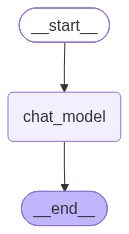

In [3]:
from IPython.display import Image, display
from langgraph.graph import MessagesState
from langgraph.graph import StateGraph, START, END

# Node
def chat_model_node(state: MessagesState):
    return {"messages": llm.invoke(state["messages"])}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("chat_model", chat_model_node)
builder.add_edge(START, "chat_model")
builder.add_edge("chat_model", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [4]:
output = graph.invoke({'messages': messages})
for m in output['messages']:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, I know about whales. But what others should I learn about?
================================== Ai Message ==================================

There’s a whole cast of fascinating marine mammals beyond the great whales. Here’s a quick guide to the most iconic groups, plus a few “under‑the‑radar” species that are worth checking out.

| Group | Typical Size | Key Traits & Fun Facts | Where You’ll Find Them |
|-------|--------------|------------------------|------------------------|
| **Dolphins** (family *Delphinidae*) | 2 – 12 ft (0.6 – 3.5 m) | Extremely social, use signature whistles, known for “surfing” bow waves. The bottlenose dolphin is the classic “dolphin” most people picture. | Temperate & tropical oceans worldwide; many coastal species prefer sh

## Reducer

A practical challenge when working with messages is managing long-running conversations. 

Long-running conversations result in high token usage and latency if we are not careful, because we pass a growing list of messages to the model.

We have a few ways to address this.

First, recall the trick we saw using `RemoveMessage` and the `add_messages` reducer.

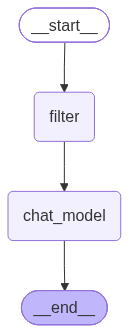

In [5]:
from langchain_core.messages import RemoveMessage

# Nodes
def filter_messages(state: MessagesState):
    # Delete all but the 2 most recent messages
    delete_messages = [RemoveMessage(id=m.id) for m in state["messages"][:-2]]
    return {"messages": delete_messages}

def chat_model_node(state: MessagesState):    
    return {"messages": [llm.invoke(state["messages"])]}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("filter", filter_messages)
builder.add_node("chat_model", chat_model_node)
builder.add_edge(START, "filter")
builder.add_edge("filter", "chat_model")
builder.add_edge("chat_model", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [6]:
# Message list with a preamble
messages = [AIMessage("Hi.", name="Bot", id="1")]
messages.append(HumanMessage("Hi.", name="Lance", id="2"))
messages.append(AIMessage("So you said you were researching ocean mammals?", name="Bot", id="3"))
messages.append(HumanMessage("Yes, I know about whales. But what others should I learn about?", name="Lance", id="4"))

# Invoke
output = graph.invoke({'messages': messages})
for m in output['messages']:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, I know about whales. But what others should I learn about?
================================== Ai Message ==================================

Sure! The ocean is home to a surprisingly diverse group of mammals beyond the iconic whales. Here’s a quick guide to the main families and some standout species you might want to explore:

---

## 1. **Dolphins (Family Delphinidae)**
* **Common Dolphin (*Delphinus delphis*)** – sleek, fast, and known for riding bow‑waves.
* **Bottlenose Dolphin (*Tursiops truncatus*)** – the “classic” dolphin most people picture; highly social and intelligent.
* **Orca or Killer Whale (*Orcinus orca*)** – the largest dolphin; apex predator with complex family pods and distinct “cultures” among different ecotypes.
* **Spinner Dolp

## Filtering messages

If you don't need or want to modify the graph state, you can just filter the messages you pass to the chat model.

For example, just pass in a filtered list: `llm.invoke(messages[-1:])` to the model.

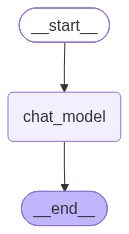

In [7]:
# Node
def chat_model_node(state: MessagesState):
    return {"messages": [llm.invoke(state["messages"][-1:])]}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("chat_model", chat_model_node)
builder.add_edge(START, "chat_model")
builder.add_edge("chat_model", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

Let's take our existing list of messages, append the above LLM response, and append a follow-up question.

In [8]:
messages.append(output['messages'][-1])
messages.append(HumanMessage(f"Tell me more about Narwhals!", name="Lance"))

In [9]:
for m in messages:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

Hi.
================================ Human Message =================================
Name: Lance

Hi.
================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, I know about whales. But what others should I learn about?
================================== Ai Message ==================================

Sure! The ocean is home to a surprisingly diverse group of mammals beyond the iconic whales. Here’s a quick guide to the main families and some standout species you might want to explore:

---

## 1. **Dolphins (Family Delphinidae)**
* **Common Dolphin (*Delphinus delphis*)** – sleek, fast, and known for riding bow‑waves.
* **Bottlenose Dolphin (*Tursiops truncatus*)** – the “classic” dolphin most people picture; highly so

In [10]:
# Invoke, using message filtering
output = graph.invoke({'messages': messages})
for m in output['messages']:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

Hi.
================================ Human Message =================================
Name: Lance

Hi.
================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, I know about whales. But what others should I learn about?
================================== Ai Message ==================================

Sure! The ocean is home to a surprisingly diverse group of mammals beyond the iconic whales. Here’s a quick guide to the main families and some standout species you might want to explore:

---

## 1. **Dolphins (Family Delphinidae)**
* **Common Dolphin (*Delphinus delphis*)** – sleek, fast, and known for riding bow‑waves.
* **Bottlenose Dolphin (*Tursiops truncatus*)** – the “classic” dolphin most people picture; highly so

The state has all of the mesages.

But, let's look at the LangSmith trace to see that the model invocation only uses the last message:

https://smith.langchain.com/public/75aca3ce-ef19-4b92-94be-0178c7a660d9/r

## Trim messages

Another approach is to [trim messages](https://docs.langchain.com/oss/python/langgraph/add-memory#trim-messages), based upon a set number of tokens. 

This restricts the message history to a specified number of tokens.

While filtering only returns a post-hoc subset of the messages between agents, trimming restricts the number of tokens that a chat model can use to respond.

See the `trim_messages` below.

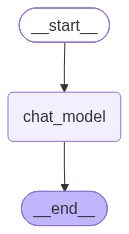

In [11]:
from langchain_core.messages import trim_messages

# Node
def chat_model_node(state: MessagesState):
    messages = trim_messages(
            state["messages"],
            max_tokens=100,
            strategy="last",
            token_counter=init_chat_model(model="openai/gpt-oss-120b", 
                model_provider="groq"),
            allow_partial=False,
        )
    return {"messages": [llm.invoke(messages)]}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("chat_model", chat_model_node)
builder.add_edge(START, "chat_model")
builder.add_edge("chat_model", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [12]:
messages.append(output['messages'][-1])
messages.append(HumanMessage(f"Tell me where Orcas live!", name="Lance"))

In [13]:
import transformers

# Example of trimming messages
trim_messages(
            messages,
            max_tokens=100,
            strategy="last",
            token_counter=llm,
            allow_partial=False
        )

c:\Users\reich\Downloads\LangChain-Academy\2 - Introduction to LangGraph\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.
c:\Users\reich\Downloads\LangChain-Academy\2 - Introduction to LangGraph\.venv\Lib\site-packages\langchain_core\language_models\base.py:463: UserWarning: Using fallback GPT-2 tokenizer for token counting. Token counts may be inaccurate for non-GPT-2 models. For accurate counts, use a model-specific method if available.
  return len(self.get_token_ids(text))


[HumanMessage(content='Tell me where Orcas live!', additional_kwargs={}, response_metadata={}, name='Lance')]

In [14]:
# Invoke, using message trimming in the chat_model_node 
messages_out_trim = graph.invoke({'messages': messages})

In [15]:
messages_out_trim

{'messages': [AIMessage(content='Hi.', additional_kwargs={}, response_metadata={}, name='Bot', id='1', tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='Hi.', additional_kwargs={}, response_metadata={}, name='Lance', id='2'),
  AIMessage(content='So you said you were researching ocean mammals?', additional_kwargs={}, response_metadata={}, name='Bot', id='3', tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='Yes, I know about whales. But what others should I learn about?', additional_kwargs={}, response_metadata={}, name='Lance', id='4'),
  AIMessage(content='Sure! The ocean is home to a surprisingly diverse group of mammals beyond the iconic whales. Here’s a quick guide to the main families and some standout species you might want to explore:\n\n---\n\n## 1. **Dolphins (Family\u202fDelphinidae)**\n* **Common Dolphin (*Delphinus delphis*)** – sleek, fast, and known for riding bow‑waves.\n* **Bottlenose Dolphin (*Tursiops truncatus*)** – the “classic” dolphin mo

Let's look at the LangSmith trace to see the model invocation:

https://smith.langchain.com/public/b153f7e9-f1a5-4d60-8074-f0d7ab5b42ef/r